# 하이테크 텍스트데이터 분석 5월말 평가 (실기)

* 이름 : 김민석                  
(이름 미추가 시 감점)

### [시험 방식]
* 이미 작성되어 있는 변수명은 그대로 사용. 수정 시 해당 풀이는 미인정
* 본 파일의 문제를 풀어 실행한 결과가 출력된 상태에서 저장
* 제출 파일 :
    * 텍스트데이터분석_5월말평가_실기_OOO.ipynb
    * monthly_exam_data_graph_OOO.png
    * monthly_exam_data_wordcloud_OOO.png
    * OOO에 본인 한글 이름 표시. 파일명이 다르거나 본인 한글 이름이 없으면 미인정
* 파일 제출 방식 : 슬랙 DM to 이혜정 교수 (시험 진행 교수가 명시한 마감 시간 이내만 제출 인정)

### 1. 주어진 파일에 있는 데이터를 데이터프레임으로 로딩하여 확인

In [33]:
import pandas as pd
datafile = 'monthly_exam_data.csv'

news_df = pd.read_csv(datafile)

# 앞에서 3개의 데이터 확인 
news_df.head(3)

,title,originallink,link,description,pubDate
0,"관광공사·카카오, 관광데이터 활용 웹·앱 개발 공모전 개최",https://www.newsis.com/view/NISX20260330_00035...,https://n.news.naver.com/mnews/article/003/001...,신용보증기금의 ‘스타트업 육성 프로그램’(<b>Start</b>-Up NEST) 서...,"Mon, 30 Mar 2026 10:24:00 +0900"
1,"[UP! <b>START</b>] 네오펙트, '다이나믹솔루션'으로 사명 변경…로봇·...",https://www.nbntv.co.kr/news/articleView.html?...,https://www.nbntv.co.kr/news/articleView.html?...,"이번 주주총회에서는 사명 변경을 위한 정관 변경 외에도 산업용 로봇, 전기 자동제어...","Thu, 26 Mar 2026 11:08:00 +0900"
2,"[스타트 경제] 백악관, 이란 종전안 거부에 &quot;협상 계속...불발땐 지옥&...",https://www.ytn.co.kr/_ln/0102_202603260726037846,https://n.news.naver.com/mnews/article/052/000...,인용 시 [YTN 뉴스<b>START</b>] 명시해주시기 바랍니다. 미국이 이란에...,"Thu, 26 Mar 2026 07:26:00 +0900"


In [34]:
# 뒤에서 3개의 데이터 확인
news_df.tail(3)

,title,originallink,link,description,pubDate
286,"대구 &quot;AI 교과서, 기대와 현실의 간극…현장 혼선 속 신뢰 회복 과제&q...",http://www.breaknews.com/1120601,http://www.breaknews.com/1120601,대구시교육청이 올해 초·중·고교에 전면 도입한 <b>인공지능</b>(AI) 디지털교...,"Wed, 28 May 2025 18:50:00 +0900"
287,온디바이스AI 합류…광주 AI‧반도체 더 강해졌다,http://www.breaknews.com/1115218,http://www.breaknews.com/1115218,‘광주형 <b>인공지능</b>(AI) 비즈니스 업무협약’(<b>280</b>~281...,"Thu, 08 May 2025 21:40:00 +0900"
288,4월 2주차 해외 ESG 핫클립,http://www.impacton.net/news/articleView.html?...,http://www.impacton.net/news/articleView.html?...,"<b>인공지능</b>(AI), 디지털 트윈 등의 기술이 포함된 이 지침서는 실질적인...","Thu, 10 Apr 2025 07:54:00 +0900"


 ### 2. news_df의 description 컬럼에 있는 데이터를 추출하여 corpus 구성 (뉴스의 리스트 형태)

In [35]:
news_corpus = news_df['description']

# 뉴스 5개 출력
news_corpus[:5]

0    신용보증기금의 ‘스타트업 육성 프로그램’(<b>Start</b>-Up NEST) 서...
1    이번 주주총회에서는 사명 변경을 위한 정관 변경 외에도 산업용 로봇, 전기 자동제어...
2    인용 시 [YTN 뉴스<b>START</b>] 명시해주시기 바랍니다. 미국이 이란에...
3    삼성전자는 지난해에 이어 올해도 ‘<b>START</b>’(전략적 기술 동맹) 프로...
4    <b>인공지능</b>을 활용해 군항제의 벚꽃 풍경과 도시 매력을 담은 영상을 제작....
Name: description, dtype: object

### 3. 데이터의 리스트를 받아서 텍스트 분석해 사용할 토큰의 리스트를 반환하는 함수 korean_tokenizer() 작성
* tokenizer로 입력된 품사 태거를 활용
* tags에 들어있는 품사의 토큰으로만 구성
* stopwords에 있는 불용어는 제거

In [36]:

def korean_tokenizer(data_list, tokenizer, tags, stopwords):
    result_tokens = [word for word, tag in tokenizer(' '.join(data_list)) if tag in tags and word not in stopwords and len(word) > 1]
    
    return result_tokens

### 4. korean_tokenizer() 함수를 활용하여 2번에서 구성한 corpus를 tokenize
* 품사 태거는 konlpy의 OKT를 활용
* 불용어 제거 : my_tags의 품사 단어만 포함, my_stopwords의 단어 제거

In [37]:
from konlpy.tag import Okt
my_tagger = Okt().pos
my_tags = ['Noun', 'Verb', 'Adjective']
my_stopwords = ['없', '같', '많', '인공지능', '인공', '지능', '하는', '했다', '통해', '이번', '한다']
news_tokens = korean_tokenizer(news_corpus, my_tagger, my_tags, my_stopwords)

len(news_tokens)

5135

### 5. Counter 라이브러리를 활용하여 news_tokens의 Counter 객체 생성

In [38]:
# news_tokens의 Counter 객체 생성
from collections import Counter
news_counter = Counter(news_tokens)


len(news_counter)

1636

In [39]:
#  news_counter로부터 빈도수 상위 30개 단어의 (단어, 빈도수) 튜플 리스트 추출하여 출력
news_counter.most_common(30)

[('스타트업', 71),
 ('기술', 60),
 ('기업', 55),
 ('산업', 52),
 ('분야', 51),
 ('기반', 45),
 ('이벤트', 40),
 ('혁신', 32),
 ('뉴스', 31),
 ('창업', 29),
 ('프로그램', 28),
 ('운영', 28),
 ('전략', 27),
 ('서비스', 26),
 ('행사', 25),
 ('미래', 24),
 ('시작', 23),
 ('로봇', 23),
 ('글로벌', 23),
 ('투자', 23),
 ('활용', 22),
 ('스타트', 22),
 ('데이터', 22),
 ('세계', 21),
 ('졸업생', 21),
 ('올해', 20),
 ('지원', 20),
 ('사업', 19),
 ('디지털', 19),
 ('독일', 19)]

### 6. news_counter에서 빈도수 상위 20개 단어를 추출하여 빈도수 수평 막대 그래프 생성하여 출력

In [40]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

In [41]:
# 그래프에 그릴 데이터 준비하여 10개씩 출력
mo = news_counter.most_common(20)
word_list = [x for x,y in mo]
count_list = [y for x,y in mo]

print(word_list[:10])
print(count_list[:10])

['스타트업', '기술', '기업', '산업', '분야', '기반', '이벤트', '혁신', '뉴스', '창업']
[71, 60, 55, 52, 51, 45, 40, 32, 31, 29]


Text(0, 0.5, '단어')

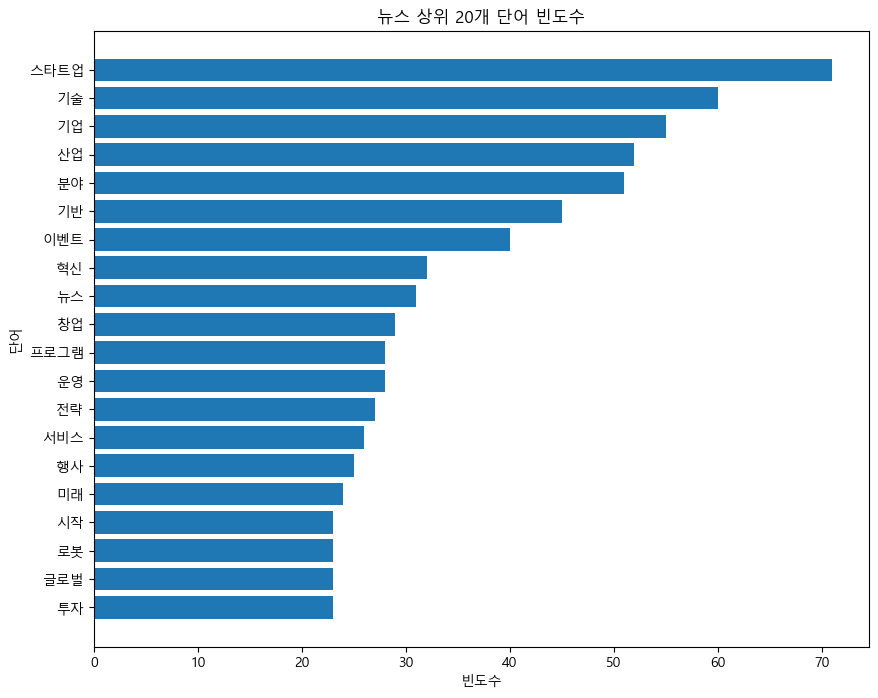

In [42]:
import matplotlib.pyplot as plt

# 빈도수가 높은 순으로 수평 막대 그래프 생성하여 출력
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(word_list[::-1], count_list[::-1])
ax.set_title(f"뉴스 상위 20개 단어 빈도수")
ax.set_xlabel("빈도수")
ax.set_ylabel("단어")

### 7. 6번의 수평 막대 그래프를 파일로 저장

In [43]:
# 저장할 파일이름 생성
# 변수 datafile에 저장된 파일이름에서 '.csv'를 '_graph_본인이름.png'로 수정하여 생성
graphfile = datafile.replace('.csv', '_graph_김민석.png')

In [44]:
# 위에서 생성한 graphfile에 6번의 수평 막대 그래프 저장
fig.savefig(graphfile)

### 8. news_counter에서 빈도수 상위 50개 단어를 추출하여 wordcloud를 생성하여 출력

In [49]:
from wordcloud import WordCloud
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성 (배경색 = 흰색, 가로 = 900, 세로 = 500)
news_wordcloud = WordCloud(font_path=font_path, 
                           background_color='white', 
                           colormap='summer',
                           max_words=50,
                           width=900,
                           height=500)


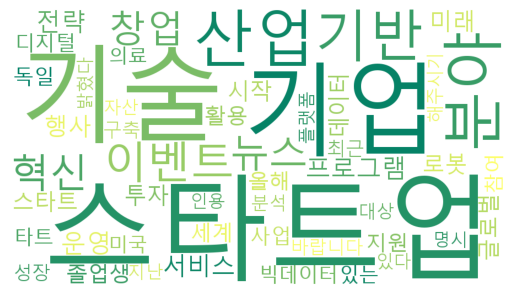

In [50]:
# 빈도 데이터로 워드클라우드 시각화
wc = news_wordcloud.generate_from_frequencies(news_counter)
plt.imshow(wc)
plt.axis('off')
plt.show()

### 9. 8번에서 생성한 wordcloud를 파일로 저장

In [51]:
# 저장할 파일이름 생성
# 변수 datafile에 저장된 파일이름에서 '.csv'를 '_wordcloud_본인이름.png'로 수정하여 생성
wordcloudfile = datafile.replace('.csv', '_wordcloud_김민석.png')

In [52]:
# wordcloudfile에 8번에서 생성한 wordcloud를 저장
wc.to_file(wordcloudfile)